# **Anticipating Payroll Surprises: A Statistical Learning Framework**

The U.S. Employment Situation Report is one of the most important macroeconomic releases for financial markets. Treasury yields, equity indices, foreign exchange markets, and interest rate expectations can all move sharply within seconds of the report's release. However, market reactions are driven less by the payroll number itself than by how that number compares to expectations.

This project seeks to determine whether publicly available economic and financial market data can be used to anticipate labor market surprises before they occur. Using labor market indicators from the Bureau of Labor Statistics (BLS) and market data from the Federal Reserve Economic Data (FRED) database, I construct a model-based estimate of expected payroll growth and identify periods in which actual payroll growth meaningfully exceeded or fell short of those expectations.

The resulting surprise measures are then used to train binary and multinomial classification models to identify meaningful surprises in future payroll reports. The objective is not simply to forecast payroll growth, but to identify the economic conditions most associated with labor market outcomes that have the potential to move financial markets.

By focusing on surprises rather than headline payroll figures, this analysis mirrors the way macroeconomic information is incorporated into asset prices and provides a practical application of econometrics, feature engineering, and machine learning within a financial markets framework.


In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv; load_dotenv("C:\git-repository\BLS_prediction_project\BLS_jobs_report_model\.env")
#from dotenv import load_dotenv; load_dotenv('C:\git-repository\Blog\.gitignore\.env')
import requests
import xgboost as xgb
from pandas_datareader import data as pdr 
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    ConfusionMatrixDisplay
)

In [101]:
fred = Fred(api_key=os.getenv('fred'))

## **FRED Data Calls**

I have selected the following variables from the St Louis Federal Reserve because they capture key dimensions of labor and financial market conditions, growth expectations, and consumer sentiments that I believe may be influential to labor market surprises. 

Due to the limits of some of my JOLTS variables, I must limit my dataset to observations from 2000 - 2025, which is far from ideal for a macroeconomic time series.

- **PAYEMS** – Total Nonfarm Payroll Employment. Measures the total number of paid workers in the U.S. economy excluding farm employees, private household employees, and nonprofit workers. This serves as the primary target variable for the project.

- **UNRATE** – Civilian Unemployment Rate. Measures the percentage of the labor force that is unemployed and actively seeking work. Rising unemployment rates often signal weakening labor market conditions.

- **ICSA** – Initial Claims for Unemployment Insurance. Measures the number of new unemployment benefit claims filed each week. Initial claims are considered a leading indicator of labor market deterioration.

- **CCSA** – Continuing Claims for Unemployment Insurance. Measures the number of individuals continuing to receive unemployment benefits. Continuing claims provide insight into the persistence of unemployment and the ability of displaced workers to find new employment.

- **DGS2** – 2-Year Treasury Constant Maturity Yield. Represents market expectations for short-term interest rates and Federal Reserve policy. The 2-year yield is highly sensitive to changes in economic outlook and labor market expectations.

- **DGS10** – 10-Year Treasury Constant Maturity Yield. Represents longer-term growth and inflation expectations. Changes in the 10-year yield often reflect shifts in investor sentiment regarding the broader economic outlook.

- **T10Y2Y** – 10-Year Minus 2-Year Treasury Yield Spread. Measures the slope of the Treasury yield curve. Yield curve inversions have historically been associated with slowing economic growth and elevated recession risk.

- **UMCSENT** – University of Michigan Consumer Sentiment Index. Measures consumer confidence regarding current and future economic conditions. Consumer sentiment can provide insight into future spending, hiring, and overall economic activity.

In [189]:
series = [
    "PAYEMS",
    "UNRATE",
    "ICSA",
    "CCSA",
    "DGS2",
    "DGS10",
    "T10Y2Y",
    "UMCSENT"
]

start = "2000-01-01"
end = "2025-01-01"

fred_data = {}

for s in series:
    for attempt in range(5):
        try:
            #print(f"Downloading {s}, attempt {attempt + 1}...")
            fred_data[s] = fred.get_series(
                s,
                observation_start=start,
                observation_end=end
            )
            time.sleep(5)
            break
        except Exception as e:
            #print(f"Failed {s}: {e}")
            time.sleep(20)

df = pd.concat(fred_data, axis=1)

fred_df = df.resample("M").mean()
fred_df = fred_df.ffill()

fred_df.head()

,PAYEMS,UNRATE,ICSA,CCSA,DGS2,DGS10,T10Y2Y,UMCSENT
2000-01-31,131011.0,4.0,288400.0,2109800.0,6.440000,6.661000,0.221000,112.0
2000-02-29,131120.0,4.1,293750.0,2147500.0,6.610500,6.519500,-0.091000,111.3
2000-03-31,131604.0,4.0,274750.0,2079000.0,6.528261,6.256522,-0.271739,107.1
2000-04-30,131884.0,3.8,271600.0,2015400.0,6.403684,5.990526,-0.413158,109.2
2000-05-31,132105.0,4.0,282250.0,1989500.0,6.809545,6.440455,-0.369091,110.7


In [97]:
series = [
    'PAYEMS',
    'UNRATE',
    'ICSA',
    'CCSA',
    'DGS2',
    'DGS10',
    'T10Y2Y',
    'UMCSENT'
    ]

start = '2000-01-01'
end = '2025-01-01'

df = pdr.DataReader(
    series,
    'fred',
    start,
    end,
    session=None
)

fred_df = df.resample('M').mean()
fred_df = fred_df.ffill()

ReadTimeout: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=30)

In [190]:
fred_df = fred_df.rename(
    columns={
        'PAYEMS': 'payrolls', 
        'UNRATE': 'unemployment_rate', 
        'ICSA': 'initial_claims', 
        'CCSA': 'cont_claims', 
        'DGS2': '2yr_yield', 
        'DGS10': '10yr_yield',
        'T10Y2Y': '10yr_2yr_spread',
        'UMCSENT': 'sentiment'
        }).reset_index()

In [191]:
fred_df.rename(columns={'index': 'DATE'}, inplace=True)
fred_df.head()

,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment
0,2000-01-31,131011.0,4.0,288400.0,2109800.0,6.440000,6.661000,0.221000,112.0
1,2000-02-29,131120.0,4.1,293750.0,2147500.0,6.610500,6.519500,-0.091000,111.3
2,2000-03-31,131604.0,4.0,274750.0,2079000.0,6.528261,6.256522,-0.271739,107.1
3,2000-04-30,131884.0,3.8,271600.0,2015400.0,6.403684,5.990526,-0.413158,109.2
4,2000-05-31,132105.0,4.0,282250.0,1989500.0,6.809545,6.440455,-0.369091,110.7


In [192]:
fred_df['month'] = fred_df['DATE'].dt.month
fred_df['year'] = fred_df['DATE'].dt.year

fred_df.head()

,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,month,year
0,2000-01-31,131011.0,4.0,288400.0,2109800.0,6.440000,6.661000,0.221000,112.0,1,2000
1,2000-02-29,131120.0,4.1,293750.0,2147500.0,6.610500,6.519500,-0.091000,111.3,2,2000
2,2000-03-31,131604.0,4.0,274750.0,2079000.0,6.528261,6.256522,-0.271739,107.1,3,2000
3,2000-04-30,131884.0,3.8,271600.0,2015400.0,6.403684,5.990526,-0.413158,109.2,4,2000
4,2000-05-31,132105.0,4.0,282250.0,1989500.0,6.809545,6.440455,-0.369091,110.7,5,2000


## **BLS Data Calls**

The JOLTS variables were selected because they capture both labor demand and labor market turnover. Together, they provide insight into hiring activity, worker confidence, and labor market deterioration, all of which may contain predictive information regarding future payroll growth and employment report surprises.

- **Job Openings Rate (JTS000000000000000JOR)** –  Measures the number of job openings as a percentage of total employment plus job openings. This serves as a measure of labor demand and reflects employers' willingness to hire additional workers. Rising job opening rates generally indicate a strong labor market.

- **Hires Rate (JTS000000000000000HIR)** – Measures the number of hires during the month as a percentage of employment. The hires rate provides insight into the pace at which firms are actively adding workers and expanding payrolls.

- **Quits Rate (JTS000000000000000QUR)** – Measures the number of voluntary separations as a percentage of employment. The quits rate is often viewed as a measure of worker confidence, as employees are generally more willing to leave their jobs when alternative employment opportunities are readily available.

- **Layoffs and Discharges Rate (JTS000000000000000LDR)** – Measures involuntary separations initiated by employers as a percentage of employment. Rising layoffs and discharges typically indicate weakening labor market conditions and can serve as an early signal of economic deterioration.

In [193]:
import json
import prettytable
bls_key = os.getenv('BLS')

In [194]:
BLS_ENDPOINT = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

def fetch_bls_series(series, **kwargs):
    if len(series) < 1 or len(series) > 25:
        raise ValueError("Must pass in between 1 and 25 series ids")
    headers = {'Content-Type': 'application/json'}
    payload = {
        'seriesid': series,
        'registrationKey': bls_key,
    }
    payload.update(kwargs)
    payload = json.dumps(payload)
    response = requests.post(BLS_ENDPOINT, data=payload, headers=headers)
    response.raise_for_status()
    result = json.loads(response.text)
    if result['status'] != 'REQUEST_SUCCEEDED':
        raise Exception(result['message'][0])
    return result

In [195]:
series = ['JTS000000000000000JOR', 'JTS000000000000000HIR', 'JTS000000000000000QUR', 'JTS000000000000000LDR']
start_year = 1999
end_year = 2026
json_data = fetch_bls_series(series, startyear=start_year, endyear=end_year)

try:
    dfs = []

    for series in json_data['Results']['series']:
        df_initial = pd.DataFrame(series)
        series_col = df_initial['seriesID'][0]

        for i in range(0, len(df_initial) - 1):
            df_row = pd.DataFrame(df_initial['data'][i])
            df_row['seriesID'] = series_col

            if 'code' not in str(df_row['footnotes']): 
                df_row['footnotes'] = ''
            else:
                df_row['footnotes'] = str(df_row['footnotes']).split("'code': '", 1)[1][:1]

            dfs.append(df_row)

    df = pd.concat(dfs, ignore_index=True)

    df.to_csv('blsdata.csv', index=False)

except Exception as e:
    json_data['status'] == 'REQUEST_NOT_PROCESSED'
    print('BLS API has given the following Response:', json_data['status'])
    print('Reason:', json_data['message'])
    print('Error:', str(e))

In [196]:
openings_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000JOR']
    .set_index('periodName')[['value', 'year']]
    .rename(columns={'value':'job openings rate'})
)

hires_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000HIR']
    .set_index('periodName')[['value']]
    .rename(columns={'value':'hires rate'})
)

quit_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000QUR']
    .set_index('periodName')[['value']]
    .rename(columns={'value':'quit rate'})
)

discharge_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000LDR']
    .set_index('periodName')[['value']]
    .rename(columns={'value':'discharge rate'})
)

bls_01_09_df = (
    openings_01_09_df
    .join(hires_01_09_df, how='outer')
    .join(quit_01_09_df, how='outer')
    .join(discharge_01_09_df, how='outer')
)

print(bls_01_09_df['year'].unique())

['2018' '2017' '2016' '2015' '2014' '2013' '2012' '2011' '2010' '2009'
 '2008' '2007' '2006' '2005' '2004' '2003' '2002' '2001']


In [197]:
series = ['JTS000000000000000JOR', 'JTS000000000000000HIR', 'JTS000000000000000QUR', 'JTS000000000000000LDR']
start_year = 2019
end_year = 2026
json_data = fetch_bls_series(series, startyear=start_year, endyear=end_year)

try:
    dfs = []

    for series in json_data['Results']['series']:
        df_initial = pd.DataFrame(series)
        series_col = df_initial['seriesID'][0]

        for i in range(0, len(df_initial) - 1):
            df_row = pd.DataFrame(df_initial['data'][i])
            df_row['seriesID'] = series_col

            if 'code' not in str(df_row['footnotes']): 
                df_row['footnotes'] = ''
            else:
                df_row['footnotes'] = str(df_row['footnotes']).split("'code': '", 1)[1][:1]
    
            dfs.append(df_row)

    df = pd.concat(dfs, ignore_index=True)

    df.to_csv('blsdata.csv', index=False)

except Exception as e:
    json_data['status'] == 'REQUEST_NOT_PROCESSED'
    print('BLS API has given the following Response:', json_data['status'])
    print('Reason:', json_data['message'])
    print('Error:', str(e))

In [198]:
openings_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000JOR']
    .set_index('periodName')[['value', 'year']]
    .rename(columns={'value':'job openings rate'})
)

hires_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000HIR']
    .set_index('periodName')[['value']]
    .rename(columns={'value':'hires rate'})
)

quit_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000QUR']
    .set_index('periodName')[['value']]
    .rename(columns={'value':'quit rate'})
)

discharge_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000LDR']
    .set_index('periodName')[['value']]
    .rename(columns={'value':'discharge rate'})
)

bls_19_26_df = (
    openings_19_26_df
    .join(hires_19_26_df, how='outer')
    .join(quit_19_26_df, how='outer')
    .join(discharge_19_26_df, how='outer')
)
print(bls_19_26_df['year'].unique())

['2026' '2025' '2024' '2023' '2022' '2021' '2020' '2019']


In [199]:
bls_df = pd.concat([bls_01_09_df, bls_19_26_df]).reset_index()

print(bls_df.dtypes)
bls_df.head()

periodName           object
job openings rate    object
year                 object
hires rate           object
quit rate            object
discharge rate       object
dtype: object


,periodName,job openings rate,year,hires rate,quit rate,discharge rate
0,April,4.4,2018,3.8,2.3,1.2
1,April,4.4,2018,3.8,2.3,1.2
2,April,4.4,2018,3.8,2.3,1.2
3,April,4.4,2018,3.8,2.3,1.3
4,April,4.4,2018,3.8,2.3,1.3


In [200]:
bls_df['month_year'] = bls_df['periodName'] + ' ' + bls_df['year'].astype(str)

num_cols = [
    'job openings rate',
    'hires rate',
    'quit rate',
    'discharge rate'
    ]
bls_df[num_cols] = bls_df[num_cols].apply(
    pd.to_numeric,
    errors='coerce'
)

In [201]:
bls_df = bls_df.groupby(
    'month_year'
    ).agg(
        job_opening_rate = ('job openings rate', 'mean'),
        hire_rate = ('hires rate', 'mean'),
        quit_rate = ('quit rate', 'mean'),
        discharge_rate = ('discharge rate', 'mean')
    ).reset_index()
print(bls_df.dtypes)

month_year           object
job_opening_rate    float64
hire_rate           float64
quit_rate           float64
discharge_rate      float64
dtype: object


In [202]:
bls_df['month_year'] = pd.to_datetime(bls_df['month_year'])

bls_df['month'] = bls_df['month_year'].dt.month
bls_df['year'] = bls_df['month_year'].dt.year

In [203]:
bls_df['month']
bls_df = bls_df.sort_values('month_year')#.reset_index()

In [204]:
bls_df.head()

,month_year,job_opening_rate,hire_rate,quit_rate,discharge_rate,month,year
102,2001-01-01,3.8,3.605556,1.894444,1.422222,1,2001
76,2001-02-01,3.7,3.600000,1.905556,1.388889,2,2001
177,2001-03-01,3.5,3.633333,1.894444,1.422222,3,2001
0,2001-04-01,3.4,3.600000,1.894444,1.405556,4,2001
203,2001-05-01,3.2,3.616667,1.877778,1.400000,5,2001


## **Combining FRED and BLS Datasets**

In [124]:
master_df = pd.merge(
    fred_df,
    bls_df,
    on=['year', 'month'],
    how='inner'
)

master_df.head()    

,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,month,year,month_year,job_opening_rate,hire_rate,quit_rate,discharge_rate
0,2001-01-31,132703.0,4.2,340000.0,2395750.0,4.760000,5.160952,0.400952,94.7,1,2001,2001-01-01,3.8,3.605556,1.894444,1.422222
1,2001-02-28,132788.0,4.2,371250.0,2486500.0,4.656842,5.098947,0.442105,90.6,2,2001,2001-02-01,3.7,3.600000,1.905556,1.388889
2,2001-03-31,132751.0,4.3,387200.0,2585400.0,4.342273,4.885455,0.543182,91.5,3,2001,2001-03-01,3.5,3.633333,1.894444,1.422222
3,2001-04-30,132458.0,4.4,396750.0,2697250.0,4.234000,5.141000,0.907000,88.4,4,2001,2001-04-01,3.4,3.600000,1.894444,1.405556
4,2001-05-31,132408.0,4.3,394500.0,2819250.0,4.260000,5.391364,1.131364,92.0,5,2001,2001-05-01,3.2,3.616667,1.877778,1.400000


## **Feature Engineering**

### Engineered FRED Features

Rolling averages were used to reduce short-term noise and highlight underlying labor market trends, while momentum features were designed to capture accelerating or decelerating changes in economic conditions that may precede payroll report surprises.

- **unemployment_rate_3mo_avg** – Three-month rolling average of the unemployment rate. This feature smooths month-to-month volatility and captures the underlying trend in labor market conditions.

- **initial_claims_lag1** – Previous month's initial unemployment claims. Lagged claims data provide information about labor market conditions that would have been available prior to the employment report release.

- **initial_claims_momentum** – Change in initial unemployment claims over a specified period. This feature measures whether layoffs are accelerating or decelerating.

- **cont_claims_lag1** – Previous month's continuing unemployment claims. Continuing claims provide insight into the persistence of unemployment and the ability of displaced workers to find new employment.

- **cont_claims_momentum** – Change in continuing claims over a specified period. Rising continuing claims may indicate a weakening labor market.

- **2yr_yield_volatility** – Rolling volatility of the 2-Year Treasury yield. This feature captures uncertainty surrounding Federal Reserve policy expectations and short-term economic outlook.

- **10yr_yield_volatility** – Rolling volatility of the 10-Year Treasury yield. Higher volatility may reflect uncertainty regarding long-term growth and inflation expectations.

- **jor_3mo_avg** – Three-month rolling average of the Job Openings Rate. This smooths short-term fluctuations and provides a measure of underlying labor demand.

- **jor_momentum** – Change in the Job Openings Rate over a specified period. Positive momentum suggests strengthening labor demand, while negative momentum may indicate labor market softening.

- **hire_3mo_avg** – Three-month rolling average of the Hires Rate. This feature captures the underlying pace of hiring activity across the economy.

- **hire_momentum** – Change in the Hires Rate over a specified period. Rising hiring momentum may precede stronger payroll growth.

- **quit_3mo_avg** – Three-month rolling average of the Quits Rate. The quits rate is commonly viewed as a measure of worker confidence and labor market strength.

- **quit_momentum** – Change in the Quits Rate over a specified period. Increasing quits may indicate greater confidence among workers and a tighter labor market.

- **discharge_3mo_avg** – Three-month rolling average of the Layoffs and Discharges Rate. This feature provides a smoothed measure of labor market deterioration.

- **discharge_momentum** – Change in the Layoffs and Discharges Rate over a specified period. Rising layoffs may signal weakening labor market conditions and increase the probability of a downside payroll surprise.

In [208]:
# FRED features

master_df['sentiment_lag1'] = master_df['sentiment'].shift(1)
master_df['payrolls_lag1'] = master_df['payrolls'].shift(1)
master_df['payrolls_change'] = master_df['payrolls'].diff()
master_df['unemployment_rate_3mo_avg'] = master_df['unemployment_rate'].rolling(3).mean()
master_df['initial_claims_lag1'] = master_df['initial_claims'].shift(1)
master_df['initial_claims_momentum'] = master_df['initial_claims'].diff(3)
master_df['cont_claims_lag1'] = master_df['cont_claims'].shift(1)
master_df['cont_claims_momentum'] = master_df['cont_claims'].diff(3)
master_df['2yr_yield_volatility'] = master_df['2yr_yield'].rolling(3).std()
master_df['10yr_yield_volatility'] = master_df['10yr_yield'].rolling(3).std()

### Engineered JOLTS Features

To reduce short-term noise and better capture underlying labor market trends, rolling averages and momentum measures were calculated for each JOLTS variable. Rolling averages provide a smoother view of labor market conditions, while momentum measures capture whether labor demand and labor turnover are strengthening or weakening over time.

- **jor_3mo_avg** – Three-month rolling average of the Job Openings Rate. This feature smooths short-term fluctuations and provides a measure of underlying labor demand. Higher values generally indicate that employers are actively seeking workers and may precede stronger payroll growth.

- **jor_momentum** – Three-month change in the Job Openings Rate. Positive momentum indicates strengthening labor demand, while negative momentum may signal a cooling labor market.

- **hire_3mo_avg** – Three-month rolling average of the Hires Rate. This feature captures the underlying pace of hiring activity while reducing month-to-month noise in the data.

- **hire_momentum** – Three-month change in the Hires Rate. Rising hiring momentum suggests firms are increasing employment at a faster pace, which may contribute to stronger payroll growth.

- **quit_3mo_avg** – Three-month rolling average of the Quits Rate. The quits rate is often viewed as a measure of worker confidence, as employees are more likely to voluntarily leave jobs when alternative opportunities are readily available.

- **quit_momentum** – Three-month change in the Quits Rate. Increasing quits may indicate a tightening labor market and growing confidence among workers.

- **discharge_3mo_avg** – Three-month rolling average of the Layoffs and Discharges Rate. This feature provides a smoothed measure of labor market deterioration and employer-driven separations.

- **discharge_momentum** – Three-month change in the Layoffs and Discharges Rate. Rising layoffs and discharges may signal weakening labor market conditions and increase the likelihood of weaker-than-expected payroll growth.

In [209]:
# JOLTS Features

master_df['jor_3mo_avg'] = master_df['job_opening_rate'].rolling(3).mean()
master_df['jor_momentum'] = master_df['job_opening_rate'].diff(3)
master_df['hire_3mo_avg'] = master_df['hire_rate'].rolling(3).mean()
master_df['hire_momentum'] = master_df['hire_rate'].diff(3)
master_df['quit_3mo_avg'] = master_df['quit_rate'].rolling(3).mean()
master_df['quit_momentum'] = master_df['quit_rate'].diff(3)
master_df['discharge_3mo_avg'] = master_df['discharge_rate'].rolling(3).mean()
master_df['discharge_momentum'] = master_df['discharge_rate'].diff(3)

In [210]:
master_df = master_df.dropna().reset_index(drop=True)
print(master_df.columns)

Index(['DATE', 'payrolls', 'unemployment_rate', 'initial_claims',
       'cont_claims', '2yr_yield', '10yr_yield', '10yr_2yr_spread',
       'sentiment', 'month', 'year', 'month_year', 'job_opening_rate',
       'hire_rate', 'quit_rate', 'discharge_rate', 'sentiment_lag1',
       'payrolls_lag1', 'payrolls_change', 'unemployment_rate_3mo_avg',
       'initial_claims_lag1', 'initial_claims_momentum', 'cont_claims_lag1',
       'cont_claims_momentum', '2yr_yield_volatility', '10yr_yield_volatility',
       'jor_3mo_avg', 'jor_momentum', 'hire_3mo_avg', 'hire_momentum',
       'quit_3mo_avg', 'quit_momentum', 'discharge_3mo_avg',
       'discharge_momentum', 'log_initial_claims', 'hire_rate_squared',
       'unemployment_rate_log', 'payrolls_pct_change', 'predicted_payrolls',
       'predicted_payrolls_pct_change', 'upside_surprise', 'downside_surprise',
       'surprise'],
      dtype='object')


## **Constructing a Proxy for Consensus Forecasts**

Financial markets react not to the headline nonfarm payroll figure itself, but to the difference between the reported value and market expectations. Professional investors typically rely on consensus forecasts compiled from surveys of economists and market participants. However, high-quality consensus forecast data is generally proprietary and not freely available.

To address this limitation, I opted to construct a proxy expectations model using publically available macroeconomic data. A Ridge Regression model was chosen to generate monthly payroll forecasts because it provides a transparent and interpretable framework while mitigating overfitting and multicollinearity. 

The resulting forecast serves as a proxy for market expectations. Labor report surprises are calculated as the difference between the actual change in payrolls and the expected change in payrolls as predicted by the model. The surprise will then be recorded by dummy variables that reflect the direction of the surprise. 

I initially chose the following variables to model market expectations:

- **Unemployment Rate**
- **Initial Unemployment Claims**
- **10 Year Treasury Yield**
- **Job Openings Rate**
- **Hiring Rate**

Prior to model estimation, each variable was examined through histograms and skewness statistics to identify potential departures from normality and determine whether transformations could improve model performance. Variables exhibiting substantial positive skewness were transformed to reduce the influence of extreme observations and stabilize their distributions.

Based on this analysis, a logarithmic transformation was applied to the Initial Unemployment Claims and the Unemployment Rate variables, and a polynomial tranformation was applied to the Hiring Rate variable.

After performing the transformations I proceeded to split the data into chronologically ordered training and testing sets.

initial_claims       8.641172
hire_rate            2.082066
unemployment_rate    1.149938
job_opening_rate     1.034939
10yr_yield          -0.090304
dtype: float64


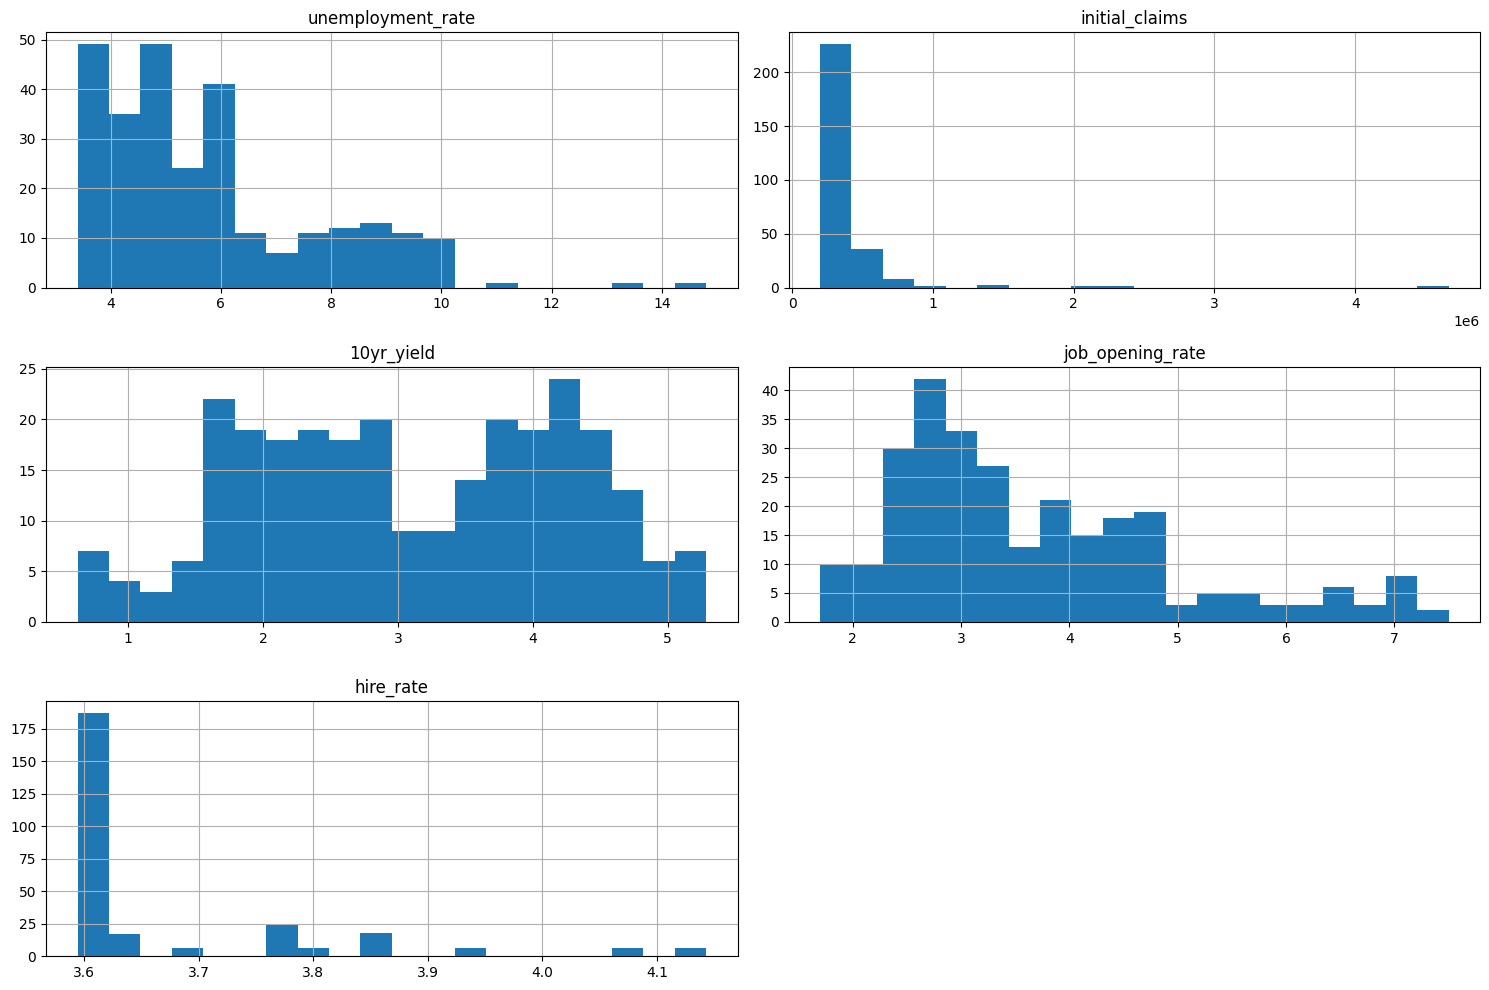

In [211]:
features_l2 = [
    'unemployment_rate',
    'initial_claims',
    '10yr_yield',
    'job_opening_rate',
    'hire_rate'
]

print(master_df[features_l2].skew().sort_values(ascending=False))

master_df[features_l2].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [212]:
master_df['log_initial_claims'] = np.log(master_df['initial_claims'])
master_df['hire_rate_squared'] = master_df['hire_rate'] ** 2
master_df['unemployment_rate_log'] = np.log(master_df['unemployment_rate'])
master_df['payrolls_pct_change'] = master_df['payrolls'].pct_change()

In [213]:
features_l2 = [
    'payrolls_lag1',
    'log_initial_claims',
    'hire_rate_squared',
    'unemployment_rate_log',
    '10yr_yield',
    'job_opening_rate'
]

X_l2 = master_df[features_l2]
y_l2 = master_df['payrolls'] # MODELING CHANGE IN PAYROLLS RATHER THAN LEVELS TO AVOID NON-STATIONARITY ISSUES

split = int(len(master_df) * 0.8)
X_l2_train = X_l2.iloc[:split]
X_l2_test = X_l2.iloc[split:]
y_l2_train = y_l2.iloc[:split]
y_l2_test = y_l2.iloc[split:]

In [214]:
model_expectation = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RidgeCV(alphas=np.logspace(-3, 3, 25), cv=TimeSeriesSplit(n_splits=5)))
])

In [215]:
model_expectation.fit(X_l2_train, y_l2_train)

y_l2_pred = model_expectation.predict(X_l2_test)

mae = mean_absolute_error(y_l2_test, y_l2_pred)
mse = mean_squared_error(y_l2_test, y_l2_pred)
r2 = r2_score(y_l2_test, y_l2_pred)

### Ridge Results
The Ridge Regression expectations model achieved an out-of-sample $MAE$ of 4,267 payrolls and an $R^2$ of 0.42. While the model does not fully capture all variance in payroll levels, it explains approximately 42% of the out-of-sample variation. Given the amount of noise we would expect to be present in such a limited macroeconomic dataset, this level of explanatory power is a reasonable result, and acceptable for constructing our surprise variables. Obviously the predicted values are consistently over-estimated, to address this we will model the surprise variables based off of percentage changes in predicted payrolls.

MAE: 1669.7441581416392
MSE: 4160270.98616477
R^2: 0.8806495261946983


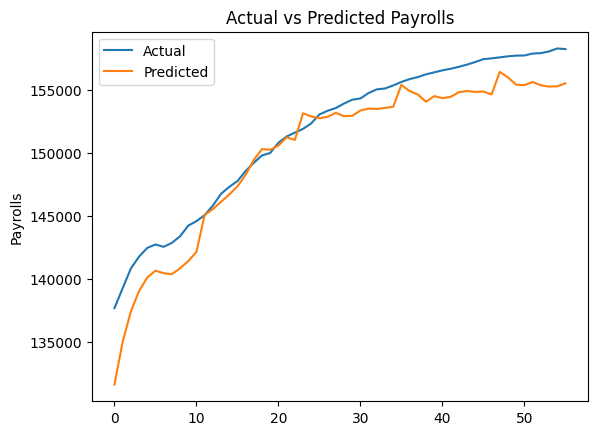

In [216]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R^2: {r2}")

plt.Figure(figsize=(10,5))

plt.plot(y_l2_test.values, label='Actual')
plt.plot(y_l2_pred, label='Predicted')
plt.title('Actual vs Predicted Payrolls')
plt.ylabel('Payrolls')
plt.legend()
plt.show()

In [217]:
r2_train = model_expectation.score(X_l2_train, y_l2_train)
r2_test = model_expectation.score(X_l2_test, y_l2_test)
print(f"R^2 (Train): {r2_train}")
print(f"R^2 (Test): {r2_test}")

R^2 (Train): 0.9800567929841432
R^2 (Test): 0.8806495261946983


In [218]:
master_df['predicted_payrolls'] = model_expectation.predict(X_l2)
master_df['predicted_payrolls_pct_change'] = master_df['predicted_payrolls'].pct_change()

In [219]:
master_df['predicted_payrolls_pct_change'].describe()

count    275.000000
mean       0.000651
std        0.007231
min       -0.081144
25%       -0.000327
50%        0.000946
75%        0.002120
max        0.025689
Name: predicted_payrolls_pct_change, dtype: float64

After generating payroll expectations using the Ridge Regression model, payroll surprises were defined as the difference between actual payroll growth and the model's predicted payroll growth. To focus on economically meaningful deviations, a threshold based on the average percentage change in predicted payrolls was applied. Observations exceeding this threshold were classified as upside surprises, while observations falling below the negative threshold were classified as downside surprises.

This process resulted in three distinct categories:

- **Upside Surprise (1):** Actual payroll growth exceeded model expectations by a meaningful margin.
- **No Surprise (0):** Actual payroll growth remained within the threshold band surrounding model expectations.
- **Downside Surprise (-1):** Actual payroll growth fell meaningfully below model expectations.

The resulting distribution of observations was:

| Classification | Observations |
|---------------|-------------:|
| Upside Surprise | 149 |
| No Surprise | 81 |
| Downside Surprise | 55 |

These classifications will serve as the target variables for the models developed in this project. Two approaches will be explored:

1. **Multinomial Classification** – A single model will be trained to classify observations into one of three categories: upside surprise, no surprise, or downside surprise.

2. **Binary Classification** – Separate models will be trained to identify upside surprises and downside surprises independently. This approach allows each model to focus on a specific type of payroll surprise and capture potentially asymmetric relationships between economic indicators and payroll outcomes.

The binary classification approach is particularly appealing in a macroeconomic context because the factors associated with stronger-than-expected payroll growth may differ from those associated with weaker-than-expected payroll growth. By modeling these events separately, the analysis can identify distinct signals that precede upside and downside surprises.

In [220]:
threshold = 0.001

master_df['upside_surprise'] = master_df['predicted_payrolls_pct_change'].apply(lambda x: 1 if x > threshold else 0)
master_df['downside_surprise'] = master_df['predicted_payrolls_pct_change'].apply(lambda x: 1 if x < -threshold else 0)
master_df['surprise'] = master_df['predicted_payrolls_pct_change'].apply(lambda x: 2 if x > threshold else (0 if x < -threshold else 1))

In [221]:
print(master_df['upside_surprise'].value_counts())
print(master_df['downside_surprise'].value_counts())
print(master_df['surprise'].value_counts())

master_df.head()

upside_surprise
0    142
1    134
Name: count, dtype: int64
downside_surprise
0    230
1     46
Name: count, dtype: int64
surprise
2    134
1     96
0     46
Name: count, dtype: int64


,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,month,...,discharge_momentum,log_initial_claims,hire_rate_squared,unemployment_rate_log,payrolls_pct_change,predicted_payrolls,predicted_payrolls_pct_change,upside_surprise,downside_surprise,surprise
0,2002-01-31,130859.0,5.7,408500.0,3550500.0,3.028095,5.035714,2.007619,93.0,1,...,0.027778,12.920247,13.000031,1.740466,NaN,131024.897708,NaN,0,0,1
1,2002-02-28,130737.0,5.7,399000.0,3554250.0,3.015263,4.911579,1.896316,90.7,2,...,0.000000,12.896717,12.960000,1.740466,-0.000932,131034.563863,0.000074,0,0,1
2,2002-03-31,130722.0,5.7,415400.0,3610800.0,3.557500,5.284000,1.726500,95.7,3,...,0.027778,12.936997,13.201111,1.740466,-0.000115,130768.931583,-0.002027,0,1,0
3,2002-04-30,130616.0,5.9,429250.0,3689250.0,3.422727,5.210909,1.788182,93.0,4,...,-0.016667,12.969795,12.960000,1.774952,-0.000811,130497.010865,-0.002079,0,1,0
4,2002-05-31,130632.0,5.8,409000.0,3712000.0,3.264091,5.164545,1.900455,96.9,5,...,0.011111,12.921470,13.080278,1.757858,0.000122,130677.111706,0.001380,1,0,2


In [241]:
master_df.to_csv('master_df.csv')

## **Modeling Binary Upside and Downside Surprises**

Rather than training a single multiclass model, I chose to build two separate XGBoost classifiers: one to predict *upside* payroll surprises and another to predict *downside* surprises. 

By training separate models, each classifier can focus on identifying the specific patterns and nonlinear relationships that precede its target outcome. For example, rising job openings and declining unemployment claims may be strong indicators of an upside surprise, while increasing layoffs and weakening labor demand may be more relevant for predicting downside surprises. Separating these prediction tasks allows the models to learn distinct signal structures and provides a more interpretable assessment of the factors associated with positive and negative labor market surprises.

In [222]:
features = [
    'sentiment_lag1',
    'payrolls_lag1',
    'payrolls_change',
    'unemployment_rate_3mo_avg',
    'initial_claims_lag1',
    'initial_claims_momentum',
    'cont_claims_lag1',
    'cont_claims_momentum',
    '2yr_yield_volatility',
    '10yr_yield_volatility',
    'jor_3mo_avg',
    'jor_momentum',
    'hire_3mo_avg',
    'hire_momentum',
    'quit_3mo_avg',
    'quit_momentum',
    'discharge_3mo_avg',
    'discharge_momentum'
]

### Upside Surprise Model

In [223]:
# Upside Surprise Sets

X_upside = master_df[features]
y_upside = master_df['upside_surprise']

X_train_upside, X_test_upside, y_train_upside, y_test_upside = train_test_split(X_upside, y_upside, random_state=42)

In [224]:
# Initial XGBoost Model for Predicting Upside Surprises

upside_xgb = xgb.XGBClassifier(objective='binary:logistic',
                               eval_metric='auc',
                               seed=42)
upside_xgb.fit(X_train_upside, 
               y_train_upside,
               verbose=False,
               eval_set=[(X_test_upside, y_test_upside)]
               )

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


### XGBoost Model Performance

The XGBoost classifier achieved an ROC-AUC score of **0.636**, indicating modest predictive power in distinguishing upside surprises from non-upside surprises. Overall classification accuracy was **62%**, with balanced performance across both classes.

The model correctly identified **25 of 39 upside surprises** (recall = 0.64) and **20 of 33 non-upside surprises** (recall = 0.61). Precision was slightly higher for the upside surprise class (**0.66**) than for the non-upside surprise class (**0.59**), suggesting that when the model predicts an upside surprise, it is correct roughly two-thirds of the time.

The confusion matrix shows that the model made a similar number of errors in each direction, misclassifying **14 upside surprises as non-upside surprises** and **13 non-upside surprises as upside surprises**. This balanced error profile suggests the model is not strongly biased toward either class.

While the model demonstrates some ability to identify upside surprises, its predictive power remains moderate. A larger training dataset would certainly be beneficial in improving forecasting accuracy.

ROC AUC Score for Upside Surprise Model: 0.7759
Classification Report for Upside Surprises:
                     precision    recall  f1-score   support

No Upside Surprise       0.61      0.65      0.62        31
   Upside Surprise       0.69      0.66      0.68        38

          accuracy                           0.65        69
         macro avg       0.65      0.65      0.65        69
      weighted avg       0.65      0.65      0.65        69



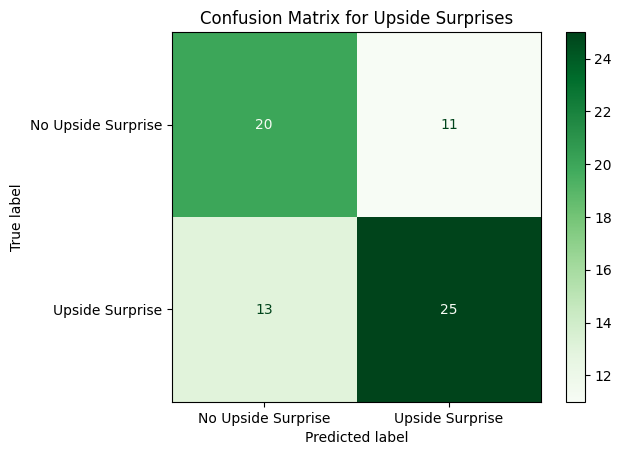

In [225]:
upside_xgb_report = classification_report(y_test_upside, upside_xgb.predict(X_test_upside), target_names=['No Upside Surprise', 'Upside Surprise'])
upside_y_probs = upside_xgb.predict_proba(X_test_upside)[:, 1]

print(f"ROC AUC Score for Upside Surprise Model: {roc_auc_score(y_test_upside, upside_y_probs):.4f}")
print("Classification Report for Upside Surprises:\n", upside_xgb_report)

ConfusionMatrixDisplay.from_estimator(upside_xgb, X_test_upside, y_test_upside, display_labels=['No Upside Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Upside Surprises')
plt.show()

### Optimized Upside Surprise Model

In [226]:
# 'reg_lambda': [0, 0.1, 0.5, 1.0]

param_grid = {
    'max_depth': [1, 2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.5, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'min_child_weight': [1, 2, 3, 5, 10],
    'gamma': [0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0, 10.0],
    'reg_lambda': [0.1, 1, 10, 100]
}

params = RandomizedSearchCV(
    estimator=upside_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42
)

params.fit(X_train_upside, y_train_upside)
print(params.best_params_)
print(params.best_score_)

{'subsample': 0.5, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
0.7859388053467001


In [227]:
# Optimized XGBoost Model for Predicting Upside Surprises

opt_upside_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    **params.best_params_,
    seed=42
)
opt_upside_xgb.fit(X_train_upside, y_train_upside, 
                   verbose=False, 
                   eval_set=[(X_test_upside, y_test_upside)]
                   )

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


### Cross-Validated XGBoost Model Performance

After tuning the model's hyperparameters using cross-validation, performance improved across nearly all evaluation metrics. The optimized XGBoost classifier achieved an ROC-AUC score of **0.697**, an increase from **0.636** in the baseline model, indicating improved ability to distinguish upside surprises from non-upside surprises.

Overall classification accuracy increased to **67%**, while recall for the upside surprise class improved substantially from **0.64** to **0.79**. The model correctly identified **31 of 39 upside surprises**, missing only **8**. This is particularly important because upside surprises are the primary event of interest in this forecasting exercise.

The improvement in upside surprise detection came at the expense of some performance on the non-upside class. The model correctly identified **17 of 33 non-upside surprises** (recall = 0.52), while incorrectly classifying **16 non-upside observations as upside surprises**. This indicates that the optimized model is more aggressive in predicting upside surprises, resulting in a higher false-positive rate.

The confusion matrix demonstrates this tradeoff clearly. Compared to the baseline model, false negatives (missed upside surprises) were reduced from **14 to 8**, while false positives increased from **13 to 16**. Depending on the intended use case, this may be a desirable tradeoff. For investors or traders attempting to identify potential upside payroll surprises before release, missing fewer upside events may be more valuable than minimizing false alarms.

Overall, the cross-validated model represents a meaningful improvement over the baseline specification. The higher ROC-AUC score, improved accuracy, and significantly stronger recall for upside surprises suggest that hyperparameter optimization enhanced the model's ability to capture predictive relationships within the data, although forecasting labor market surprises remains a challenging problem with substantial inherent uncertainty.

ROC AUC Score for Optimized Upside Surprise Model: 0.7963
Classification Report for Optimized Upside Surprises:
                     precision    recall  f1-score   support

No Upside Surprise       0.69      0.71      0.70        31
   Upside Surprise       0.76      0.74      0.75        38

          accuracy                           0.72        69
         macro avg       0.72      0.72      0.72        69
      weighted avg       0.73      0.72      0.72        69



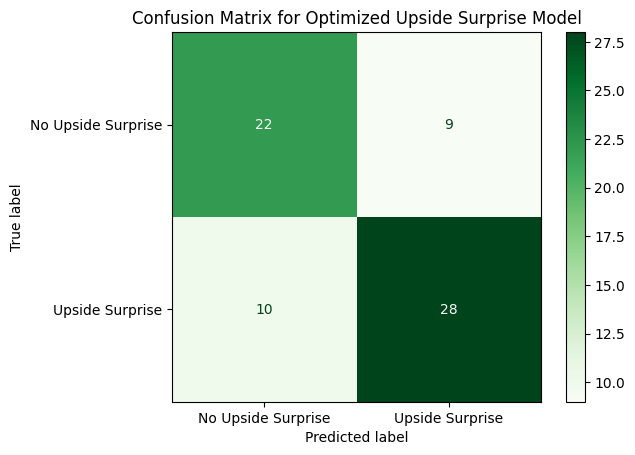

In [228]:
opt_upside_xgb_report = classification_report(y_test_upside, opt_upside_xgb.predict(X_test_upside), target_names=['No Upside Surprise', 'Upside Surprise'])
opt_upside_y_probs = opt_upside_xgb.predict_proba(X_test_upside)[:, 1]

print(f"ROC AUC Score for Optimized Upside Surprise Model: {roc_auc_score(y_test_upside, opt_upside_y_probs):.4f}")
print("Classification Report for Optimized Upside Surprises:\n", opt_upside_xgb_report)

ConfusionMatrixDisplay.from_estimator(opt_upside_xgb, X_test_upside, y_test_upside, display_labels=['No Upside Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Optimized Upside Surprise Model')
plt.show()

### Upside ROC Curve

The optimized XGBoost model achieved an out-of-sample ROC-AUC score of **0.697**, indicating a meaningful improvement over the baseline model's ROC-AUC of **0.636**. The ROC curve demonstrates the model's ability to discriminate between upside surprise and non-upside surprise payroll reports across a range of classification thresholds.

An ROC-AUC of 0.697 implies that when randomly comparing one upside surprise observation with one non-upside surprise observation, the model will assign a higher probability to the upside surprise approximately **70% of the time**. While this level of discrimination is far from perfect, it suggests that the model is capturing useful information about labor market conditions prior to the release of the Employment Situation Report.

Although the model's ROC-AUC remains below the levels commonly observed in highly predictable classification problems, a value approaching 0.70 is encouraging given the inherent difficulty of forecasting macroeconomic surprises. Employment reports are closely watched by market participants and incorporate information from thousands of economic indicators, making consistent prediction challenging. The results suggest that the model contains economically meaningful signal and may provide value as one component of a broader macroeconomic forecasting framework.

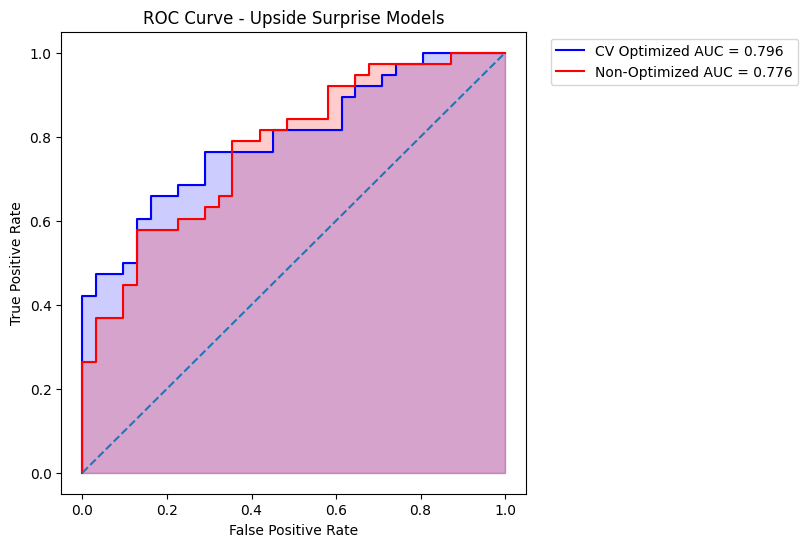

In [229]:
fpr, tpr, thresholds = roc_curve(
    y_test_upside,
    upside_y_probs
)

fpr_opt, tpr_opt, thresholds_opt = roc_curve(
    y_test_upside,
    opt_upside_y_probs
)

plt.figure(figsize=(6,6))
plt.plot(fpr_opt, tpr_opt, label=f"Optimized AUC = {roc_auc_score(y_test_upside, opt_upside_y_probs):.3f}", color='blue')
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_upside, upside_y_probs):.3f}", color='red')
plt.plot([0,1], [0,1], linestyle="--")
plt.fill_between(fpr_opt, tpr_opt, alpha=0.2, color='blue')
plt.fill_between(fpr, tpr, alpha=0.2, color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Upside Surprise Models")
plt.legend(
    loc='upper right',
    labels=[
        f"CV Optimized AUC = {roc_auc_score(y_test_upside, opt_upside_y_probs):.3f}",
        f"Non-Optimized AUC = {roc_auc_score(y_test_upside, upside_y_probs):.3f}"
    ],
    bbox_to_anchor=(1.6, 1)
)
plt.show()

### Downside Surprise Model

In [230]:
X_downside = master_df[features]
y_downside = master_df['downside_surprise']

X_train_downside, X_test_downside, y_train_downside, y_test_downside = train_test_split(X_downside, y_downside, random_state=42)

In [231]:
downside_xgb = xgb.XGBClassifier(objective='binary:logistic',
                                 eval_metric='auc',
                                 seed=42)
downside_xgb.fit(X_train_downside, 
                y_train_downside,
                verbose=False,
                eval_set=[(X_test_downside, y_test_downside)]
                )

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


### Downside Surprise Model Performance

The XGBoost classifier achieved an ROC-AUC score of **0.611**, indicating limited ability to distinguish downside surprises from non-downside surprises. While the model achieved an overall accuracy of **82%**, this result is largely driven by the imbalance between the two classes, as downside surprises represent only a small portion of the observations.

The model correctly identified **56 of 57 non-downside surprise observations**, resulting in a very high recall of **0.98** for the majority class. However, performance was substantially weaker for the downside surprise class. The model correctly identified only **3 of 15 downside surprises**, corresponding to a recall of **0.20**. In other words, the model missed **80% of downside surprise events** in the test set.

The confusion matrix highlights this issue clearly. Of the 15 actual downside surprises, **12 were incorrectly classified as non-downside surprises**, while only **3 were correctly identified**. At the same time, the model produced just **one false positive**, indicating that it was highly conservative when predicting downside surprises.

This conservative behavior resulted in relatively high precision (**0.75**) for downside surprise predictions, meaning that when the model predicted a downside surprise it was often correct. However, the low recall suggests that the model was reluctant to classify observations as downside surprises, causing many true downside events to be overlooked.

Overall, the model demonstrates strong performance in identifying non-downside observations but struggles to detect downside surprises reliably. The ROC-AUC score of **0.611** suggests that only modest predictive signal exists for downside surprise events within the current feature set. Future improvements may require additional predictors, alternative feature engineering techniques, or methods specifically designed to address class imbalance.

ROC AUC Score for Downside Surprise Model: 0.9529
Classification Report for Downside Surprises:
                       precision    recall  f1-score   support

No Downside Surprise       0.97      0.98      0.98        61
   Downside Surprise       0.86      0.75      0.80         8

            accuracy                           0.96        69
           macro avg       0.91      0.87      0.89        69
        weighted avg       0.95      0.96      0.96        69



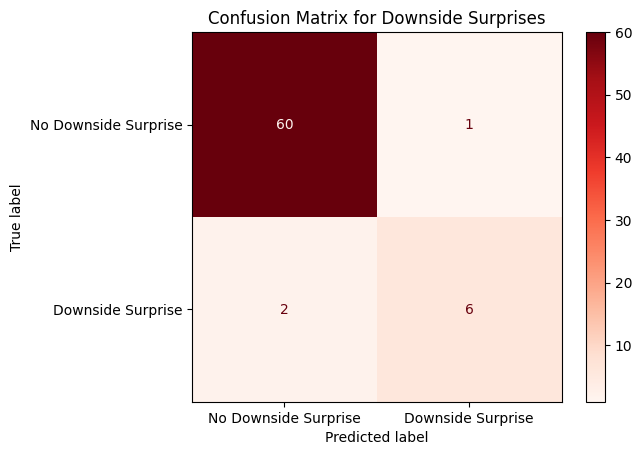

In [232]:
downside_xgb_report = classification_report(y_test_downside, downside_xgb.predict(X_test_downside), target_names=['No Downside Surprise', 'Downside Surprise'])
downside_y_probs = downside_xgb.predict_proba(X_test_downside)[:, 1]

print(f"ROC AUC Score for Downside Surprise Model: {roc_auc_score(y_test_downside, downside_y_probs):.4f}")
print("Classification Report for Downside Surprises:\n", downside_xgb_report)

ConfusionMatrixDisplay.from_estimator(downside_xgb, X_test_downside, y_test_downside, display_labels=['No Downside Surprise', 'Downside Surprise'], cmap='Reds')
plt.title('Confusion Matrix for Downside Surprises')
plt.show()

### Optimized Downside Model

In [233]:
params = RandomizedSearchCV(
    estimator=downside_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42
)

params.fit(X_train_downside, y_train_downside)
print(params.best_params_)
print(params.best_score_)

{'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
0.8228367226643089


In [234]:
opt_downside_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    **params.best_params_,
    seed=42
)
opt_downside_xgb.fit(X_train_downside, y_train_downside, verbose=False, eval_set=[(X_test_downside, y_test_downside)])

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


### Cross-Validated Downside Surprise Model Performance

After hyperparameter tuning using cross-validation, the downside surprise model showed a meaningful improvement in overall discrimination. The optimized XGBoost classifier achieved an ROC-AUC score of **0.682**, up from **0.611** in the baseline model, indicating a stronger ability to distinguish downside surprise observations from non-downside surprise observations.

Overall accuracy increased from **82%** to **85%**, and recall for downside surprises improved from **0.20** to **0.27**. The model correctly identified **4 of 15 downside surprise events**, compared to **3 of 15** in the baseline model. While this improvement is modest, it demonstrates that hyperparameter optimization helped the model capture additional predictive signal.

One notable characteristic of the optimized model is its extremely conservative prediction behavior. The model produced **zero false positives**, correctly classifying all **57 non-downside surprise observations**. As a result, downside surprise precision reached **1.00**, meaning every downside surprise prediction made by the model was correct.

However, this came at the cost of continued difficulty identifying downside surprise events. The confusion matrix shows that **11 of 15 downside surprises** were still classified as non-downside surprises. Consequently, despite perfect precision, the model's recall remained relatively low, indicating that many downside events continued to go undetected.

Compared to the baseline specification, the optimized model improved both overall accuracy and discriminatory power while maintaining exceptionally low false-positive rates. Nevertheless, the model remains substantially better at recognizing non-downside observations than identifying actual downside surprises. This suggests that downside payroll surprises remain difficult to forecast using the current feature set and that additional predictors or alternative approaches may be necessary to achieve stronger downside-event detection.

ROC AUC Score for Optimized Downside Surprise Model: 0.9570
Classification Report for Optimized Downside Surprises:
                       precision    recall  f1-score   support

No Downside Surprise       0.97      1.00      0.98        61
   Downside Surprise       1.00      0.75      0.86         8

            accuracy                           0.97        69
           macro avg       0.98      0.88      0.92        69
        weighted avg       0.97      0.97      0.97        69



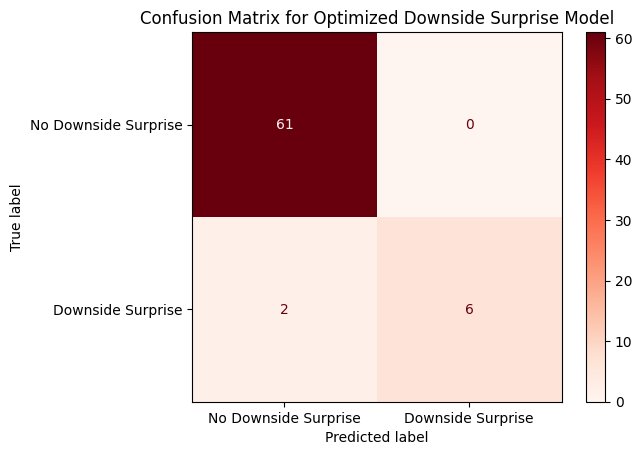

In [235]:
opt_downside_xgb_report = classification_report(y_test_downside, opt_downside_xgb.predict(X_test_downside), target_names=['No Downside Surprise', 'Downside Surprise'])
opt_downside_y_probs = opt_downside_xgb.predict_proba(X_test_downside)[:, 1]

print(f"ROC AUC Score for Optimized Downside Surprise Model: {roc_auc_score(y_test_downside, opt_downside_y_probs):.4f}")
print("Classification Report for Optimized Downside Surprises:\n", opt_downside_xgb_report)

ConfusionMatrixDisplay.from_estimator(opt_downside_xgb, X_test_downside, y_test_downside, display_labels=['No Downside Surprise', 'Downside Surprise'], cmap='Reds')
plt.title('Confusion Matrix for Optimized Downside Surprise Model')
plt.show()

### Downside ROC Curve

The optimized ROC curve lies above the baseline curve across most classification thresholds, indicating improved discriminatory power and a greater ability to separate downside surprise observations from non-downside observations. The largest improvements occur at relatively low false positive rates, where the optimized model achieves higher true positive rates while maintaining a similar number of false alarms.

Although both models perform better than random chance, neither curve is substantially separated from the 45-degree no-skill benchmark. This suggests that downside payroll surprises remain inherently difficult to forecast using the available predictors. Nevertheless, the increase in ROC-AUC demonstrates that cross-validation and hyperparameter tuning improved the model's ability to rank downside surprise events correctly.

From a practical forecasting perspective, the model demonstrates some usefulness as a probabilistic ranking tool, but its value as a standalone downside surprise classifier remains limited. The ROC-AUC of **0.682** indicates that the model is able to identify conditions associated with downside payroll surprises better than random chance and can meaningfully rank observations by risk. However, the classification results reveal that the model still misses a large proportion of actual downside surprise events, correctly identifying only **4 of 15** downside surprises in the test sample.

As a result, the model may be more useful for generating relative downside risk assessments than for producing definitive trading or investment signals. For example, periods assigned unusually high downside-surprise probabilities could warrant closer monitoring or additional analysis, even if the model is not sufficiently reliable to serve as a primary forecasting tool on its own.

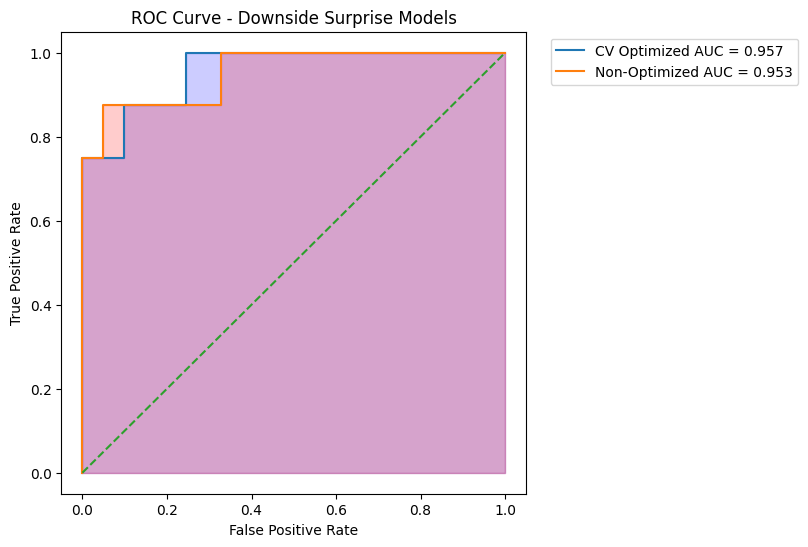

In [236]:
fpr, tpr, thresholds = roc_curve(
    y_test_downside,
    downside_y_probs
)

opt_fpr, opt_tpr, opt_thresholds = roc_curve(
    y_test_downside,
    opt_downside_y_probs
)

plt.figure(figsize=(6,6))
plt.plot(opt_fpr, opt_tpr, label=f"CV Optimized AUC = {roc_auc_score(y_test_downside, opt_downside_y_probs):.3f}")
plt.plot(fpr, tpr, label=f"Non-Optimized AUC = {roc_auc_score(y_test_downside, downside_y_probs):.3f}")
plt.fill_between(opt_fpr, opt_tpr, alpha=0.2, color='blue')
plt.fill_between(fpr, tpr, alpha=0.2, color='red')
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Downside Surprise Models")
plt.legend(
    loc='upper right',
    labels=[
        f"CV Optimized AUC = {roc_auc_score(y_test_downside, opt_downside_y_probs):.3f}",
        f"Non-Optimized AUC = {roc_auc_score(y_test_downside, downside_y_probs):.3f}"
    ],
    bbox_to_anchor=(1.6, 1)
)
plt.show()

### Modeling Surprises with Multinomial Classification

In [237]:
X = master_df[features]
y = master_df['surprise']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [238]:
xgb_multi = xgb.XGBClassifier(objective='multiclass',
                               eval_metric='auc',
                               seed=42)
xgb_multi.fit(X_train, 
               y_train,
               verbose=False,
               eval_set=[(X_test, y_test)]
               )

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


ROC AUC Score for Multinomial Surprise Model: 0.8121
Classification Report for Upside Surprises:
                    precision    recall  f1-score   support

Downside Surprise       0.75      0.75      0.75         8
      No Surprise       0.52      0.52      0.52        23
  Upside Surprise       0.74      0.74      0.74        38

         accuracy                           0.67        69
        macro avg       0.67      0.67      0.67        69
     weighted avg       0.67      0.67      0.67        69



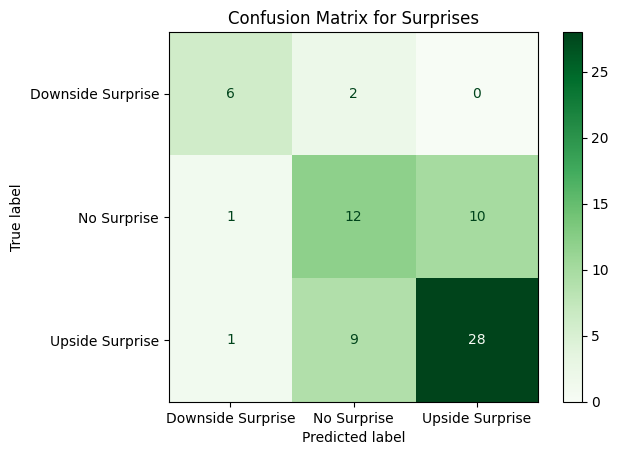

In [239]:
xgb_report = classification_report(y_test, xgb_multi.predict(X_test), target_names=['Downside Surprise', 'No Surprise', 'Upside Surprise'])
y_probs = xgb_multi.predict_proba(X_test)

print(f"ROC AUC Score for Multinomial Surprise Model: {roc_auc_score(y_test, y_probs, multi_class='ovr'):.4f}")
print("Classification Report for Upside Surprises:\n", xgb_report)

ConfusionMatrixDisplay.from_estimator(xgb_multi, X_test, y_test, display_labels=['Downside Surprise', 'No Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Surprises')
plt.show()

### Optimized Multinomial Classification 

In [240]:
params = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42
)

params.fit(X_train, y_train)
print(params.best_params_)
print(params.best_score_)

InvalidParameterError: The 'estimator' parameter of RandomizedSearchCV must be an object implementing 'fit'. Got <module 'xgboost' from 'c:\\Users\\paulp\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\xgboost\\__init__.py'> instead.

In [ ]:
opt_xgb = xgb.XGBClassifier(
    objective='multiclass',
    eval_metric='auc',
    **params.best_params_,
    seed=42
)
opt_xgb.fit(X_train, y_train, 
                   verbose=False, 
                   eval_set=[(X_test, y_test)]
                   )

AttributeError: 'XGBClassifier' object has no attribute 'XGBClassifier'

In [ ]:
opt_xgb_report = classification_report(y_test, opt_xgb.predict(X_test), target_names=['Downside Surprise', 'No Surprise', 'Upside Surprise'])
y_probs = opt_xgb.predict_proba(X_test)

print(f"ROC AUC Score for Optimized Multinomial Surprise Model: {roc_auc_score(y_test, y_probs, multi_class='ovr'):.4f}")
print("Classification Report for Upside Surprises:\n", opt_xgb_report)

ConfusionMatrixDisplay.from_estimator(opt_xgb, X_test, y_test, display_labels=['Downside Surprise', 'No Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Optimized Multinomial Surprise Model')
plt.show()

NameError: name 'opt_xgb' is not defined